<a href="https://colab.research.google.com/github/kaushikyash02/100Days-ML/blob/main/PlacementPredictionDay13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import numpy as np
import pandas as pd

In [66]:
df = pd.read_csv('/content/placement.csv')

In [67]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [69]:
df.shape

(100, 4)

In [70]:
df = df.iloc[:,1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


# Steps

0. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

In [71]:
import matplotlib.pyplot as plt

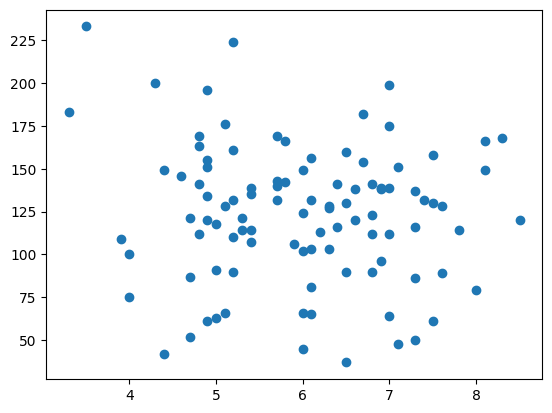

In [72]:
plt.scatter(df['cgpa'],df['iq'])

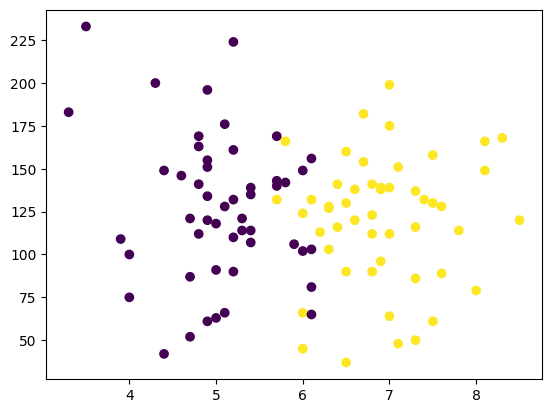

In [73]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [74]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [75]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [76]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [77]:
from sklearn.model_selection import train_test_split

train_test_split(X,y,test_size=0.2)

[    cgpa     iq
 13   6.4  116.0
 49   5.4  135.0
 36   5.7  140.0
 85   5.8  166.0
 28   5.2   90.0
 ..   ...    ...
 53   8.3  168.0
 14   6.1  103.0
 17   3.3  183.0
 51   4.8  141.0
 60   6.9  139.0
 
 [80 rows x 2 columns],
     cgpa     iq
 23   4.7   87.0
 50   3.5  233.0
 73   4.9   61.0
 42   7.6   89.0
 9    5.1   66.0
 44   7.5   61.0
 45   6.0   66.0
 92   5.2  110.0
 68   4.0   75.0
 25   5.0   91.0
 22   4.9  120.0
 59   4.8  112.0
 65   8.1  166.0
 24   4.7  121.0
 20   6.6  120.0
 91   7.5  158.0
 16   5.2  224.0
 63   6.3  128.0
 52   7.0  175.0
 77   7.3   50.0,
 13    1
 49    0
 36    0
 85    1
 28    0
      ..
 53    1
 14    0
 17    0
 51    0
 60    1
 Name: placement, Length: 80, dtype: int64,
 23    0
 50    0
 73    0
 42    1
 9     0
 44    1
 45    1
 92    0
 68    0
 25    0
 22    0
 59    0
 65    1
 24    0
 20    1
 91    1
 16    0
 63    1
 52    1
 77    1
 Name: placement, dtype: int64]

In [78]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.1)

In [79]:
X_train

,cgpa,iq
77,7.3,50.0
95,4.3,200.0
46,5.3,114.0
42,7.6,89.0
10,6.0,45.0
...,...,...
58,8.0,79.0
40,4.9,134.0
12,5.4,139.0
72,7.3,116.0


In [80]:
y_train

,placement
77,1
95,0
46,0
42,1
10,1
...,...
58,1
40,0
12,0
72,1


In [81]:
X_test

,cgpa,iq
79,6.5,90.0
9,5.1,66.0
7,5.0,63.0
14,6.1,103.0
13,6.4,116.0
69,8.5,120.0
92,5.2,110.0
17,3.3,183.0
62,6.0,102.0
0,6.8,123.0


In [82]:
y_test

,placement
79,1
9,0
7,0
14,0
13,1
69,1
92,0
17,0
62,0
0,1


In [83]:
from sklearn.preprocessing import StandardScaler #for scaling

scaler = StandardScaler()

In [84]:
X_train = scaler.fit_transform(X_train)
X_train

array([[ 1.16107969e+00, -1.87811589e+00],
       [-1.52292302e+00,  1.86039259e+00],
       [-6.28255448e-01, -2.83018938e-01],
       [ 1.42947996e+00, -9.06103685e-01],
       [-1.98815015e-03, -2.00273284e+00],
       [-1.79132329e+00, -1.25503114e+00],
       [-9.86122476e-01, -1.33478599e-01],
       [-1.07558923e+00, -3.32865718e-01],
       [-1.88079004e+00, -4.07635887e-01],
       [ 7.13745905e-01, -3.32865718e-01],
       [-5.38788691e-01, -4.57482667e-01],
       [-1.80921664e-01,  4.14835978e-01],
       [ 8.74786067e-02, -1.50426504e+00],
       [-1.16505599e+00, -1.82826911e+00],
       [-1.79132329e+00, -6.31946396e-01],
       [-1.07558923e+00,  9.38227165e-01],
       [ 1.16107969e+00, -9.80873854e-01],
       [ 1.87681374e+00,  5.89299707e-01],
       [ 8.92679418e-01, -1.52918843e+00],
       [-1.80921664e-01,  1.01299733e+00],
       [ 1.25054645e+00,  1.65602079e-01],
       [ 2.05574726e+00,  1.06284411e+00],
       [ 1.34001320e+00, -1.60395860e+00],
       [ 9.

In [85]:
X_test = scaler.fit_transform(X_test)
X_test

array([[ 0.46882869, -0.55015045],
       [-0.60717158, -1.30035561],
       [-0.68402875, -1.39413126],
       [ 0.16140004, -0.14378932],
       [ 0.39197153,  0.26257181],
       [ 2.00597195,  0.387606  ],
       [-0.53031442,  0.07502052],
       [-1.99060051,  2.35689455],
       [ 0.08454288, -0.17504787],
       [ 0.69940018,  0.48138165]])

In [86]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

In [87]:
clf.fit(X_train,y_train) #model training

LogisticRegression()

In [88]:
y_pred = clf.predict(X_test)

In [89]:
from sklearn.metrics import accuracy_score

In [90]:
accuracy_score(y_test,y_pred)

0.8

In [92]:
# Decision boundry
from mlxtend.plotting import plot_decision_regions

<Axes: >

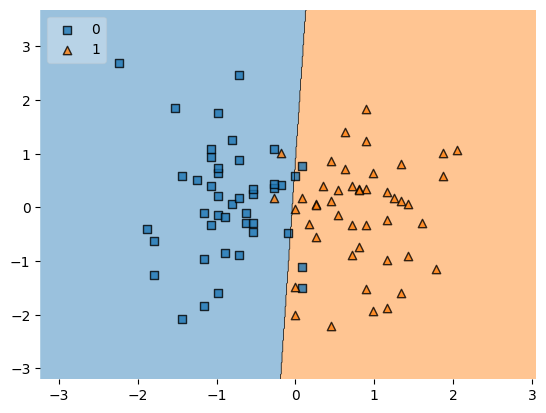

In [95]:
plot_decision_regions(X_train,y_train.values,clf=clf,legend=2)

In [96]:
import pickle

In [97]:
pickle.dump(clf,open('model.pkl','wb'))